# 一個固定的 Flow Matching 框架，怎麼同時用在影像與軌跡 policy 的生成問題上？

U2 一開始有 demo 過 2D 點雲上的 Flow Matching。雖然看起來很成功，但就這樣一個框架：把資料換成一張影像，或換成一段機器人的動作，方法到底要改哪裡？難道都不用改嗎？

先 summarize 一下答案：**Flow Matching 的 training 方式與 sampling 方式不用重寫。** 至於不同情境，只要補上兩件事：

1. 一筆資料 $X_1$，或是 conditional 情境下的 $(X_1,c)$，長什麼樣子；
2. approximate velocity field 的 neural network 長怎樣、要吃什麼、吐出什麼。

這次的實作我們會帶大家走過：

| 時間 | 內容 |
| --- | --- |
| 0–5 min | 把不會變的 Flow Matching training 與 sampling 收進同一個 class |
| 5–15 min | 影像生成：從 real image data 退回 8×8 的兩方塊 toy |
| 15–28 min | 動作與軌跡 policy：從 Push-T 退回繞過障礙的 action chunk toy |
| 28–30 min | 把兩個情境放回同一個框架比較 |

兩個情境都會經過五個步驟：

$$
\text{problem setting}
\rightarrow \text{toy example}
\rightarrow \text{data properties}
\rightarrow \text{Flow Matching}
\rightarrow \text{results}.
$$

> **這個實作會作為幫助大家完成專題與作業的前置任務——接著就要遠征三大頂會了！**


In [ ]:
import math, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

START_TIME = time.time()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def set_seed(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)
print("device:", DEVICE)


## 0. 先把不會變的部分收進同一個 class

我們先把 U2 已經看過的 unconditional setting 寫回來。從資料分布抽 $X_1$、從起點分布抽 $X_0$，再用 linear interpolation

$$
I_t=(1-t)X_0+tX_1,
\qquad
\dot I_t=X_1-X_0
$$

把兩端連起來。

這次多寫了一個課堂上還沒有正式引進的符號 $c$。它代表生成時已經知道、而且希望模型拿來決定答案的 **condition**。在 conditional setting 裡，一筆資料不是單獨的 $X_1$，而是一起出現的一對

$$
(X_1,c)\sim p_{\text{data}}(x_1,c).
$$

例如在 policy learning 裡，$c=s$ 是現在看到的 state，$X_1=A_{0:H-1}$ 是這個 state 對應的一段動作。兩者必須從同一筆示範一起抽；不能把某個 state 和另一條示範的動作隨便配起來。

抽到 $(X_1,c)$ 後，我們另外獨立抽 $X_0\sim p_0$。Interpolation 只作用在 $X_0$ 與 $X_1$ 上；$c$ 不會被加 noise，也不會沿著 $t$ 改變，而是固定交給 velocity network：

$$
I_t=(1-t)X_0+tX_1,
\qquad
v_\theta(I_t,t,c).
$$

因此 conditional Flow Matching 的 objective 是

$$
\mathcal L(\theta)
=\mathbb E_{\substack{t,\,X_0,\\(X_1,c)\sim p_{\text{data}}}}
\left[\left\|v_\theta(I_t,t,c)-(X_1-X_0)\right\|^2\right].
$$

如果問題沒有 condition，就把 $c$ 省略；程式裡設成 `None`。Sampling 時則固定想 conditioning 的 $c$，從 $X_0$ 出發解

$$
\frac{\mathrm dX_t}{\mathrm dt}=v_\theta(X_t,t,c)
$$

一路走到 $t=1$。

下面寫的 `FlowMatching` class 只負責三件事：定義 loss、`fit`、`sample`。它不需要知道 $X$ 是影像還是一段動作。

`FlatVelocityNetwork` 很明顯只是一個偷懶：先把一筆資料攤平，預測 velocity 後再折回原本的 shape。它不是影像或軌跡最合理的 neural network；這堂先用它作為測試，讓我們把注意力放在「同一個 Flow Matching 框架怎麼套到不同資料」上。


In [ ]:
def time_features(t, n_freq=4):
    # (B,) -> (B, 1 + 2*n_freq)
    t = t.reshape(-1, 1)
    k = (2 ** torch.arange(n_freq, device=t.device, dtype=t.dtype)) * math.pi
    return torch.cat([t, torch.sin(t * k), torch.cos(t * k)], dim=1)


class FlatVelocityNetwork(nn.Module):
    # 把任意 sample shape 攤平；condition c 維持 (B, cond_dim)。

    def __init__(self, sample_shape, cond_dim=0, hidden=256, layers=3, n_freq=4):
        super().__init__()
        self.sample_shape = tuple(sample_shape)
        self.cond_dim = cond_dim
        self.n_freq = n_freq
        data_dim = math.prod(self.sample_shape)
        in_dim = data_dim + (1 + 2 * n_freq) + cond_dim

        blocks = []
        for _ in range(layers):
            blocks += [nn.Linear(in_dim, hidden), nn.SiLU()]
            in_dim = hidden
        blocks.append(nn.Linear(in_dim, data_dim))
        self.net = nn.Sequential(*blocks)

    def forward(self, x, t, c=None):
        batch = len(x)
        pieces = [x.reshape(batch, -1), time_features(t, self.n_freq)]
        if self.cond_dim:
            if c is None:
                raise ValueError("This velocity network requires a condition c.")
            pieces.append(c.reshape(batch, self.cond_dim))
        velocity = self.net(torch.cat(pieces, dim=1))
        return velocity.reshape_as(x)


class FlowMatching:
    # Linear Flow Matching shared by both examples below.

    def __init__(self, velocity, lr=2e-3):
        self.velocity = velocity
        self.lr = lr

    def loss(self, x0, x1, c=None):
        batch = len(x0)
        t = torch.rand(batch, device=x0.device)
        t_view = t.reshape(batch, *([1] * (x0.ndim - 1)))
        xt = (1 - t_view) * x0 + t_view * x1
        target_velocity = x1 - x0
        return ((self.velocity(xt, t, c) - target_velocity) ** 2).mean()

    def fit(self, get_batch, steps, name="model"):
        optimizer = torch.optim.Adam(self.velocity.parameters(), lr=self.lr)
        history = []
        report_every = max(1, steps // 5)
        for step in range(1, steps + 1):
            loss = self.loss(*get_batch())
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            history.append(loss.item())
            if step == 1 or step % report_every == 0:
                print(f"[{name}] step {step:4d}/{steps}: loss = {np.mean(history[-report_every:]):.4f}")
        return history

    @torch.no_grad()
    def sample(self, x0, c=None, steps=30):
        # Heun integration from t=0 to t=1.
        x = x0.clone()
        dt = 1.0 / steps
        batch = len(x)
        for i in range(steps):
            t0 = torch.full((batch,), i / steps, device=x.device)
            t1 = torch.full((batch,), (i + 1) / steps, device=x.device)
            v0 = self.velocity(x, t0, c)
            proposal = x + dt * v0
            v1 = self.velocity(proposal, t1, c)
            x = x + 0.5 * dt * (v0 + v1)
        return x


---

# A. 影像生成

## A1. Problem setting：真實影像資料長什麼樣子？

對電腦來說，一張影像是一個陣列。灰階影像可以寫成

$$
X_1\in\mathbb R^{1\times H\times W},
$$

彩色影像則是 $X_1\in\mathbb R^{3\times H\times W}$。下面從左到右放了一張彩色照片、8×8 的手寫 digits，以及 28×28 的 Fashion-MNIST。它們的內容不同，但對生成模型來說，問題都是要從 $p_{\text{data}}(x)$ 生成一整個 pixel array。


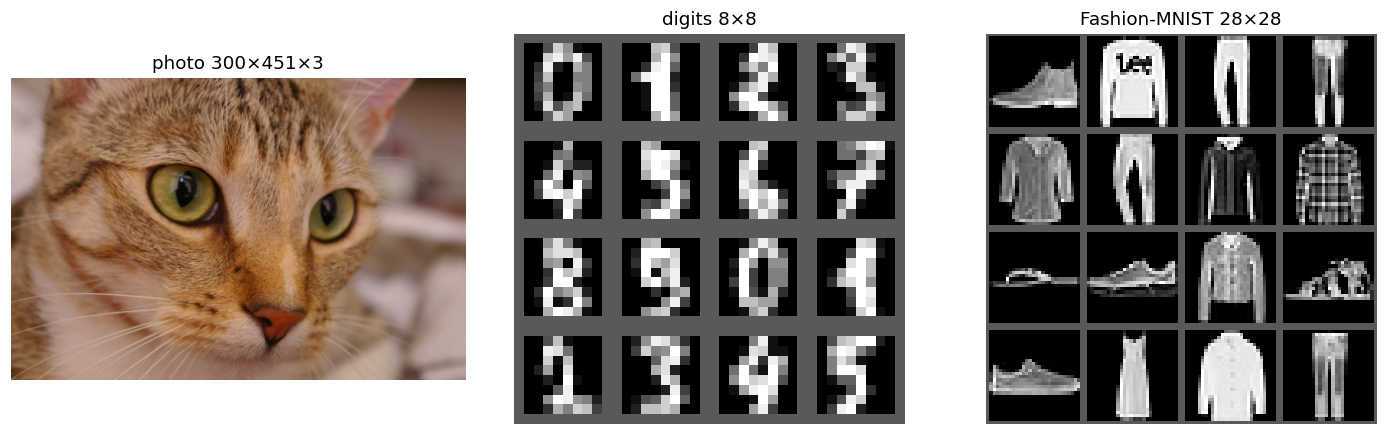

In [ ]:
# 這張 real-data preview 已經存進 cell output；下面的相對路徑讓它也能重新顯示。
from pathlib import Path
from IPython.display import Image, display

preview_path = Path("dma-u2-flow-matching-assets/real-image-data.png")
if preview_path.exists():
    display(Image(filename=str(preview_path)))
else:
    print("找不到 preview asset；請重新開啟 notebook 以查看已嵌入的 cell output。")


真實影像的麻煩也在這裡：維度很高，而且隨便填一組 pixel values，幾乎不會得到一張合理的影像。我們沒有辦法直接把這個高維 distribution 畫出來，也很難逐一列出所有合法答案。

## A2. Toy example：兩個方塊必須在同一列

所以 toy 不能只是「把圖縮小」；它要保留剛才那個困難，同時讓正確答案可以被完整列出來。

我們使用 8×8 灰階圖。每張圖都有兩個 2×2 方塊：一個在左半邊、一個在右半邊，而且兩個方塊一定同高。總共有

$$
7\times 3\times 3=63
$$

個模板；每次先均勻挑一個模板，再替每個 pixel 加一點 Gaussian noise。

這個 toy 拿掉了物體、材質、光線與高解析度，但保留了我們要研究的 data property：**合法影像只集中在少數 modes 周圍，pixel-wise average 通常不在其中。**


In [ ]:
IMAGE_SIGMA = 0.06

templates = []
for row in range(7):
    for left_col in range(3):
        for right_col in range(4, 7):
            image = np.zeros((1, 8, 8), dtype=np.float32)
            image[:, row:row + 2, left_col:left_col + 2] = 1.0
            image[:, row:row + 2, right_col:right_col + 2] = 1.0
            templates.append(image)

IMAGE_TEMPLATES = torch.tensor(np.stack(templates))
N_IMAGE_MODES = len(IMAGE_TEMPLATES)

def sample_image_data(n):
    mode = torch.randint(0, N_IMAGE_MODES, (n,))
    return IMAGE_TEMPLATES[mode] + IMAGE_SIGMA * torch.randn(n, 1, 8, 8)

def show_images(images, title, n=12):
    images = np.asarray(images)[:n, 0]
    fig, axes = plt.subplots(1, len(images), figsize=(1.15 * len(images), 1.45))
    axes = np.atleast_1d(axes)
    for ax, image in zip(axes, images):
        ax.imshow(image, cmap="gray", vmin=-0.15, vmax=1.15)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

set_seed(1)
image_examples = sample_image_data(12)
print("one image:", tuple(image_examples.shape[1:]))
print("one batch:", tuple(image_examples.shape))
show_images(image_examples, "training samples: two squares at the same height")


## A3. Data properties：平均值仍是一個陣列，但通常不是一張合法的圖

這份資料有三個直接看得見的性質：

- 一筆資料的 shape 是 `(1, 8, 8)`；模型實際要同時生成 64 個數字。
- 資料有 63 個 modes；每張合法圖都靠近其中一個模板。
- 兩張合法圖逐 pixel 平均後，常會出現四個半亮方塊，離開原本的 63 個 modes。

先猜：下面兩張圖的 pixel-wise average，還會不會符合「兩個方塊同高」？


In [ ]:
set_seed(3)
x_a, x_b = sample_image_data(2)
x_mean = 0.5 * (x_a + x_b)
show_images(torch.stack([x_a, x_b, x_mean]), "two samples, then their pixel-wise average", n=3)


## A4. Flow Matching：把影像 shape 填進共用演算法

現在只要回答開頭的兩個問題：

| 要補的設定 | 影像 toy 裡的答案 |
| --- | --- |
| $X_1$ | 一張 `(1, 8, 8)` 影像 |
| $X_0$ | 同 shape 的 Gaussian noise |
| condition $c$ | 沒有，設成 `None` |
| velocity network | `(image, t) → image-shaped velocity` |

在這個小例子裡，我們用 MLP。注意下一格沒有重寫 loss，也沒有重寫 ODE solver；我們只是建立 network，然後告訴共用 class 一個 batch 要怎麼抽。


In [ ]:
set_seed(10)
image_velocity = FlatVelocityNetwork(
    sample_shape=(1, 8, 8),
    cond_dim=0,
    hidden=256,
    layers=3,
).to(DEVICE)
image_flow = FlowMatching(image_velocity, lr=2e-3)

def image_batch(batch_size=256):
    x1 = sample_image_data(batch_size).to(DEVICE)
    x0 = torch.randn_like(x1)
    return x0, x1, None

image_history = image_flow.fit(image_batch, steps=3000, name="image")


## A5. Results：生成結果有沒有回到 63 個 modes？

這個 toy 讓我們可以直接量兩件事：

- **valid rate**：生成影像離最近模板夠不夠近；
- **mode coverage**：63 個模板中，有多少個至少被生成一次。

這裡不需要再加別的影像任務。只要確認生成的 samples 不再是 pixel average，而且能覆蓋不同模板，就已經回答了這一段的問題。


In [ ]:
@torch.no_grad()
def image_metrics(images, threshold=3 * IMAGE_SIGMA):
    images = images.cpu()
    distance = ((images[:, None] - IMAGE_TEMPLATES[None]) ** 2).mean(dim=(2, 3, 4)).sqrt()
    nearest_distance, nearest_mode = distance.min(dim=1)
    valid = nearest_distance < threshold
    covered = nearest_mode[valid].unique().numel()
    return {
        "valid_rate": valid.float().mean().item(),
        "mode_coverage": int(covered),
        "nearest_distance": nearest_distance.numpy(),
    }

set_seed(11)
n_image_samples = 1200
image_noise = torch.randn(n_image_samples, 1, 8, 8, device=DEVICE)
generated_images = image_flow.sample(image_noise, steps=30).cpu()
image_result = image_metrics(generated_images)

print(f"valid rate:   {image_result['valid_rate']:.1%}")
print(f"mode coverage: {image_result['mode_coverage']}/{N_IMAGE_MODES}")
show_images(generated_images, "Flow Matching samples", n=12)

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.hist(image_result["nearest_distance"], bins=40, color="tab:blue", alpha=0.8)
ax.axvline(3 * IMAGE_SIGMA, color="tab:red", linestyle="--", label="valid threshold")
ax.set_xlabel("RMS distance to the nearest template")
ax.set_ylabel("count")
ax.legend()
plt.show()


---

# B. 動作與軌跡 policy learning

## B1. Problem setting：真實的 trajectory policy 看見什麼、生成什麼？

先看 Push-T：機器人用圓形末端把灰色的 T 形物塊推到綠色目標。不同初始狀態需要不同動作，而且同一個任務可能有不只一條成功路徑。下圖前三格是不同初始狀態，最後一格是 image-based policy 會看到的 observation。


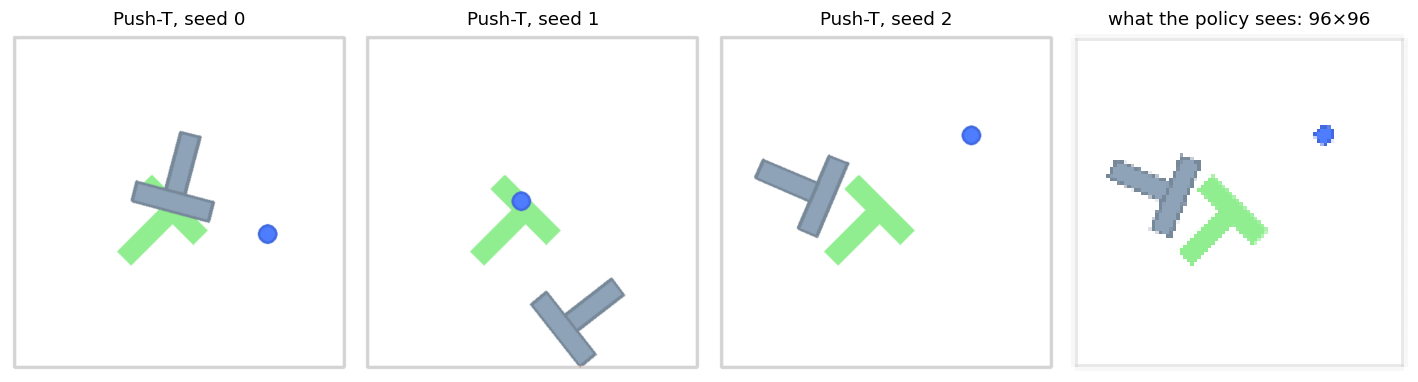

In [ ]:
# 這張 real-data preview 已經存進 cell output；下面的相對路徑讓它也能重新顯示。
from pathlib import Path
from IPython.display import Image, display

preview_path = Path("dma-u2-flow-matching-assets/pusht-benchmark.png")
if preview_path.exists():
    display(Image(filename=str(preview_path)))
else:
    print("找不到 preview asset；請重新開啟 notebook 以查看已嵌入的 cell output。")


真實設定裡，condition $c$ 可以包含 camera image、robot state 或過去幾步 observation；生成的 $X_1$ 則可以是一個 action，或是一段 action chunk。這次我們選第二種：

$$
X_1=A_{0:H-1}=(a_0,a_1,\ldots,a_{H-1})\in\mathbb R^{H\times 2}.
$$

每個 $a_h=(\Delta x_h,\Delta y_h)$ 是一步二維位移；把這些動作累加起來，就得到一條 trajectory。為了看清 condition 的角色，我們只留下目前 state

$$
c=s=(x,y),
$$

所以這次學的是 $p(A_{0:H-1}\mid s)$。

## B2. Toy example：同一個起點，可以從左邊或右邊繞過障礙

Push-T 同時包含 image perception、contact dynamics、物體旋轉與控制。這些都很真實，但會遮住我們現在要看的問題。於是 toy 把機器人簡化成一個點：從接近 $(0,-1)$ 的位置出發，要走到 $(0,1)$；原點有一個圓形障礙。每一筆示範會隨機選左邊或右邊，兩條路都正確。

我們用 $H=24$ 個動作描述整條路。這個 toy 拿掉 perception、接觸與物體動力學，但保留 policy data 最重要的 property：**同一個 state 下，可以有不只一個正確的 action chunk；把它們平均，可能反而失敗。**


In [ ]:
HORIZON = 24
OBSTACLE_RADIUS = 0.30
GOAL = np.array([0.0, 1.0], dtype=np.float32)

def make_trajectory_demos(n=5000):
    start_x = np.random.uniform(-0.12, 0.12, size=n)
    state = np.stack([start_x, -np.ones(n)], axis=1)
    side = np.where(np.random.rand(n) < 0.5, -1.0, 1.0)
    amplitude = np.random.uniform(0.52, 0.62, size=n)

    u = np.linspace(0.0, 1.0, HORIZON + 1)
    x = (1 - u[None]) * start_x[:, None] + side[:, None] * amplitude[:, None] * np.sin(np.pi * u)[None]
    y = -1.0 + 2.0 * u[None]
    y = np.repeat(y, n, axis=0)
    positions = np.stack([x, y], axis=2).astype(np.float32)
    actions = np.diff(positions, axis=1).astype(np.float32)
    return state.astype(np.float32), actions, positions, side.astype(np.float32)

def draw_world(ax):
    ax.add_patch(plt.Circle((0, 0), OBSTACLE_RADIUS, color="0.25", alpha=0.25))
    ax.plot(*GOAL, "*", color="tab:green", ms=13)
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

set_seed(20)
STATE_DEMO, ACTION_DEMO, POSITION_DEMO, SIDE_DEMO = make_trajectory_demos()
print("one state:", STATE_DEMO.shape[1:])
print("one action chunk:", ACTION_DEMO.shape[1:])
print("one trajectory (including start):", POSITION_DEMO.shape[1:])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for path, side in zip(POSITION_DEMO[:80], SIDE_DEMO[:80]):
    ax.plot(path[:, 0], path[:, 1], color="tab:blue" if side < 0 else "tab:orange", alpha=0.45, lw=0.9)
draw_world(ax)
ax.set_title("80 demonstrations")
plt.show()


## B3. Data properties：平均動作看起來合理，累積後卻穿過障礙

對接近 $(0,-1)$ 的同一個 state，示範的第一個橫向動作有兩群：往左、或往右。中間不是第三種走法；它只是兩群的平均。

因為 trajectory 是 action 的累積，我們不能只檢查單一步。下面把同一批示範的 action chunks 平均，再從起點一路加回去。先猜：**平均 trajectory 會從哪裡經過？**


In [ ]:
def actions_to_positions(states, actions):
    cumulative = np.cumsum(actions, axis=1)
    return np.concatenate([states[:, None], states[:, None] + cumulative], axis=1)

near_center = np.abs(STATE_DEMO[:, 0]) < 0.01
center_actions = ACTION_DEMO[near_center]
mean_actions = center_actions.mean(axis=0, keepdims=True)
mean_path = actions_to_positions(np.array([[0.0, -1.0]], dtype=np.float32), mean_actions)[0]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(center_actions[:, 0, 0], bins=40, color="tab:blue", alpha=0.8)
ax[0].axvline(center_actions[:, 0, 0].mean(), color="black", linestyle="--", label="mean")
ax[0].set_xlabel("first action: Δx")
ax[0].set_ylabel("count")
ax[0].set_title("same state, two action modes")
ax[0].legend()

for path in POSITION_DEMO[near_center][:40]:
    ax[1].plot(path[:, 0], path[:, 1], color="0.75", lw=0.8)
ax[1].plot(mean_path[:, 0], mean_path[:, 1], color="black", linestyle="--", lw=2.5, label="mean action chunk")
draw_world(ax[1])
ax[1].set_title("the mean trajectory goes through the obstacle")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## B4. Flow Matching：只換 data shape 與 condition

共用演算法沒有改。這次填入的是：

| 要補的設定 | 軌跡 policy toy 裡的答案 |
| --- | --- |
| $X_1$ | `(24, 2)` 的 action chunk |
| $X_0$ | 同 shape 的 Gaussian noise |
| condition $c$ | 目前 state `(x, y)` |
| velocity network | `(action chunk, t, state) → action-shaped velocity` |

動作的量級大約是 $0.1$，所以先除以 `ACTION_SCALE` 再訓練。這只是資料 normalization，不會改變 Flow Matching 的 objective。


In [ ]:
ACTION_SCALE = 0.10
STATE_TENSOR = torch.tensor(STATE_DEMO, device=DEVICE)
ACTION_TENSOR = torch.tensor(ACTION_DEMO / ACTION_SCALE, device=DEVICE)

set_seed(21)
trajectory_velocity = FlatVelocityNetwork(
    sample_shape=(HORIZON, 2),
    cond_dim=2,
    hidden=256,
    layers=3,
).to(DEVICE)
trajectory_flow = FlowMatching(trajectory_velocity, lr=2e-3)

def trajectory_batch(batch_size=256):
    index = torch.randint(0, len(STATE_TENSOR), (batch_size,), device=DEVICE)
    x1 = ACTION_TENSOR[index]
    x0 = torch.randn_like(x1)
    condition = STATE_TENSOR[index]
    return x0, x1, condition

trajectory_history = trajectory_flow.fit(trajectory_batch, steps=3500, name="trajectory policy")


## B5. Results：生成的 action chunks 有沒有保留左右兩種答案？

我們固定同一個 state $s=(0,-1)$，重複生成很多 action chunks，再把每一段動作累積成 trajectory。結果只讀三件事：

- 有多少條 trajectory 碰到障礙；
- 最後有沒有走到 goal 附近；
- 通過障礙時，走左與走右的比例是否都不是零。

這裡的重點不是做完整的 robotics benchmark，而是確認 conditional Flow Matching 沒有把兩個正確答案壓成中間的平均。


In [ ]:
def trajectory_metrics(paths):
    distance_to_obstacle = np.linalg.norm(paths[:, :, :2], axis=2)
    collision = (distance_to_obstacle < OBSTACLE_RADIUS).any(axis=1)
    goal_error = np.linalg.norm(paths[:, -1] - GOAL[None], axis=1)
    success = (~collision) & (goal_error < 0.18)
    midpoint_x = paths[:, HORIZON // 2, 0]
    return {
        "collision_rate": collision.mean(),
        "success_rate": success.mean(),
        "left_rate": (midpoint_x < 0).mean(),
    }

set_seed(22)
n_trajectories = 400
query_state = torch.tensor([[0.0, -1.0]], device=DEVICE).repeat(n_trajectories, 1)
trajectory_noise = torch.randn(n_trajectories, HORIZON, 2, device=DEVICE)
generated_actions = trajectory_flow.sample(
    trajectory_noise,
    c=query_state,
    steps=30,
).cpu().numpy() * ACTION_SCALE
generated_paths = actions_to_positions(query_state.cpu().numpy(), generated_actions)
policy_result = trajectory_metrics(generated_paths)

print(f"collision rate: {policy_result['collision_rate']:.1%}")
print(f"success rate:   {policy_result['success_rate']:.1%}")
print(f"left / right:   {policy_result['left_rate']:.1%} / {1-policy_result['left_rate']:.1%}")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.4))
for path in generated_paths[:60]:
    color = "tab:blue" if path[HORIZON // 2, 0] < 0 else "tab:orange"
    ax[0].plot(path[:, 0], path[:, 1], color=color, alpha=0.35, lw=0.9)
draw_world(ax[0])
ax[0].set_title("Flow Matching trajectory samples")

for path in POSITION_DEMO[near_center][:30]:
    ax[1].plot(path[:, 0], path[:, 1], color="0.80", lw=0.7)
ax[1].plot(mean_path[:, 0], mean_path[:, 1], "k--", lw=2.5, label="mean action chunk")
draw_world(ax[1])
ax[1].set_title("MSE target: conditional mean")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


---

# 把兩個情境放回同一張表

| | 影像生成 | 動作與軌跡 policy |
| --- | --- | --- |
| 一筆 $X_1$ | `(1, 8, 8)` image | `(24, 2)` action chunk |
| condition $c$ | `None` | current state `(x, y)` |
| $X_0$ | 和 $X_1$ 同 shape 的 Gaussian noise | 和 $X_1$ 同 shape 的 Gaussian noise |
| network | image-shaped velocity | action-chunk-shaped velocity，並額外看 state |
| sample 如何讀 | 直接 reshape 成影像 | 將 actions 累積成 trajectory |

回到開頭的問題：**換領域時，Flow Matching 的核心演算法沒有換。** 我們真正換掉的是 data representation、condition，以及配合它們的 velocity network。

影像 toy 告訴我們：平均 pixel array 不一定落在合法 image modes 上。軌跡 toy 則把同一件事變得更具體：左繞與右繞的平均，會直接穿過障礙。Flow Matching 學的是整個 distribution，因此同一個 condition 下仍然可以生成不同、但都合理的答案。


In [ ]:
print(f"total runtime: {(time.time() - START_TIME) / 60:.1f} min")
